# Feature Extraction from Audio Signal with <code>librosa
We follow https://www.kdnuggets.com/2020/02/audio-data-analysis-deep-learning-python-part-1.html<br>

We illustrate the use of <code>librosa</code>, a package for music and audio analysis.

## Table of Contents:
[1. Load Audio File, Waveform and Spectrogram](#first-bullet)<br>
[2. Feature Extraction from Audio Signal](#second-bullet)<br>
[5. Summary: From Signal to Mel-Frequency Cepstral Coefficients (MFCCs)](#fifth-bullet)<br>

#### Preamble

In [2]:
from scipy import signal
from scipy.io import wavfile    # load wave files
import librosa                  # package for music and audio analysis
import librosa.display
import IPython.display as ipyd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Audio File, Waveform and Spectrogram<a class="anchor" id="first-bullet"></a>

### Load Audio File

#### <code>scipy.io</code>

We can use <code>scipy.io.wavfile.read()</code> to load an audio file into a time series and extract the sample rate:<br>

<code>sr, x = wavfile.read(filename)</code><br>

The output <code>sr</code> is the sample rate and <code>x</code> is the time series as a numpy array.<br>

#### <code>librosa</code>

We can use <code>librosa.load()</code> to load an audio file and extract the sample rate:<br>

<code>x, sr = wavfile.read(path, sr=22050, mono=True, offset=0.0, duration=None)</code><br>

Arguments:<br>
<code>sr</code>: sample rate. <code>None</code> means use the native sample rate of the file<br>
<code>mono</code>: convert the signal to mono<br>
<code>offset</code>: start reading after this time (in seconds)<br>
<code>duration</code>: only load up to this much audio (in seconds)<br>
    
Outputs:<br>
<code>x</code>: time series as a numpy array. \* Here we use the notations <code>x</code> and <code>y</code> interchangeably<br>
<code>sr</code>: sample rate

### Plotting waveform
    
<code>librosa.display.waveshow(y, sr=22050, max_points=11025, x_axis='time', offset=0.0, ...)</code>

Arguments:<br>
<code>max_points</code>: Maximum number of samples to draw. If the number of raw samples in <code>y</code> exceeds <code>max_points</code>, the series is downsampled before the waveform is drawn.<br>
<code>x_axis</code>: <code>'time'</code>: values are plotted in second  <br>
<code>offset</code>: horizontal offset (in seconds) to start the waveform plot<br>

### Spectrogram

See DFT, STFT, Spectrograms and MFCCs.ipynb for a review on short-time Fourier transform (STFT).<br>

1. Compute the STFT of the signal

<code>stfft = librosa.stft(y, n_fft=2048, hop_length=None, ...) </code><br>

2. Convert ampltide of STFT to decibel scale

<code>stfftdB = librosa.amplitude_to_db(np.abs(stfft), ref=1.0, ...) </code>

Arguments:<br>
<code>ref</code>: the amplitude abs(X) is scaled relative to ref: $20\log_{10}(X/\text{ref})$. Zeros in the output correspond to positions where S == ref<br>

3. Plot spectrogram

<code>librosa.display.specshow(stfftdB, sr=22050, hop_length=512, fmin=None, fmax=None, ...) </code>

Arguments:<br>
<code>hop_length</code>: i.e. stride length of STFT in unit of number of samples<br>
<code>x_axis, y_axis</code>: see documentation for options <br>

https://librosa.org/doc/main/generated/librosa.display.specshow.html?highlight=specshow


### Load Audio File

In [82]:
# filename = 'violin_A.wav'
filename = 'bruckner.wav'

# use scipy.io.wavfile.read() to load audio file
# extract sample rate f_x and signal x
# sr, x = wavfile.read(filename)
# x = x / 1.0  # convert to float

# use librosa.load() to load audio file
# x , sr = librosa.load(filename, sr=None)
x , sr = librosa.load(filename, sr=None, offset=0.1)

# play audio on IPython
ipyd.Audio(rate=sr, data=y)

In [83]:
x

array([ 5.0354004e-03,  2.1362305e-04, -4.8828125e-03, ...,
       -1.2207031e-04,  1.2207031e-04, -9.1552734e-05], dtype=float32)

In [84]:
sr

44100

### Waveform plot

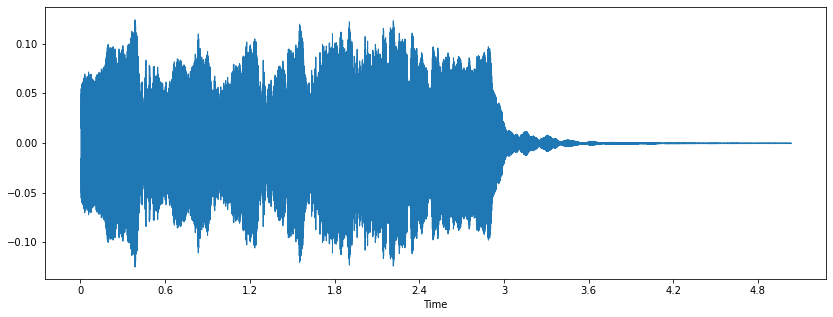

In [85]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(x, sr=sr);

### Spectrogram

In [135]:
# Short-time fast Fourier transform (STFFT)
n_fft = int(0.025*sr)  # 25ms
hop_length = int(0.01*sr)  # 10ms
stfft = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)
abs_stfft = np.abs(stfft)

stfftdB = librosa.amplitude_to_db(abs_stfft, ref=np.max)

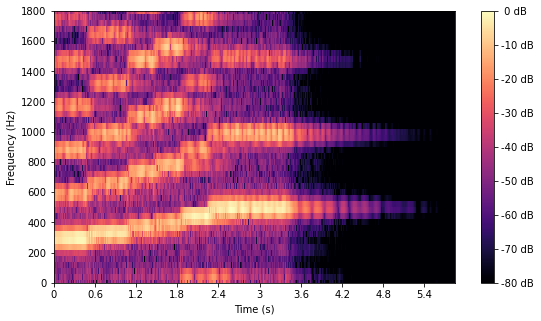

In [136]:
# Plot spectrogram
fig, ax = plt.subplots(figsize=(9,5))
img = librosa.display.specshow(stfftdB, sr=sr, 
                        y_axis='hz', x_axis='time', ax=ax, fmax=6000)
plt.xlabel('Time (s)')
plt.ylabel("Frequency (Hz)")
plt.ylim([0, 1800])
fig.colorbar(img, ax=ax, format="%2.0f dB");

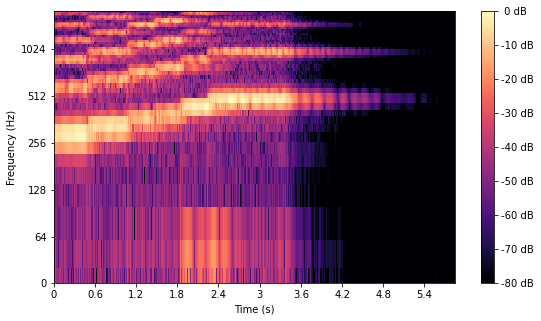

In [137]:
# Plot spectrogram, frequency in log scale
fig, ax = plt.subplots(figsize=(9,5))
img = librosa.display.specshow(stfftdB, sr=sr, 
                        y_axis='log', x_axis='time', ax=ax, fmax=6000)
plt.xlabel('Time (s)')
plt.ylabel("Frequency (Hz)")
plt.ylim([0, 1800])
fig.colorbar(img, ax=ax, format="%2.0f dB");

# 2. Feature Extraction from Audio Signal<a class="anchor" id="second-bullet"></a>

Useful function: <br>

<code>librosa.frames_to_time(frames, sr=22050, hop_length=512, n_fft=None)</code><br>

converts frame counts to time (seconds).<br>
<br>

In addition to the STFT which we visualise with a spectrogram, we want to extract useful features from the signal. Here we look at some **spectral features (frequency-based features)**:

#### 1. Spectral Centroid

The **spectral centroid** $f_c$ is defined as the mean of the frequencies present in the signal weighed by their magnitudes, aka the *'centre of mass' frequency* of the signal:

$$ f_c\equiv \frac{\sum_k |X_k|f_k}{\sum_k |X_k|} \tag{1}$$

It is implemented by <br>

<code>librosa.feature.spectral_centroid(y=None, sr=22050, n_fft=2048, hop_length=512, ...)</code><br>


#### 2. Spectral Rolloff

The **spectral rolloff** is the frequency below which a specified percentage (e.g. 85%) of the total spectral energy lies.<br>

<code>librosa.feature.spectral_rolloff(y=None, sr=22050, n_fft=2048, hop_length=512, roll_percent=0.85, ...)</code><br>


#### 3. Spectral Bandwidth

The **order-$p$ spectral bandwidth** is defined as<br>

$$ \left( \sum_k S_k(t)\times (f_k(t) - \text{centroid}(t))^p\right)^{\frac{1}{p}} \tag{2},$$

where $S_k(t)$ is the magnitude of the spectrogram.<br>

<code>librosa.feature.spectral_bandwidth(y=None, sr=22050, n_fft=2048, hop_length=512, p=2)</code><br>


#### 4. Zero-Crossing Rate

The **zero-crossing rate (ZCR)** is rate at which a signal changes from positive to zero to negative or from negative to zero to positive; given a signal $x_t$ of length $T$, <br>

$$\text{ZCR }\equiv \frac{1}{T}\sum_{t=0}^{T-1}\mathbb{I}\{x_t x_{t-1} < 0\}, \tag{3} $$

where $\mathbb{I}\{y\}$ is an **indicator function**: it is 1 if $y$ is true and 0 otherwise.<br>
The ZRC is usually higher for highly percussive sounds like those in metal and rock.<br>

<code>librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512, ...)</code><br>

<code>frame_length</code>: I think it is the same as <code>n_fft</code><br>


#### 5. Mel-Frequency Cepstral Coefficients(MFCCs)

The first dozen or so MFCCs concisely describe the overall shape of a spectral envelope, and model the characteristics of the human voice. See DFT, STFT, Spectrograms and MFCCs.ipynb for a review on the workflow of obtaining the MFCCs.<br>

<code>mfcc = librosa.feature.mfcc(y=None, sr=22050, S=None, n_mfcc=20, dct_type=2, norm='ortho', lifter=0, **kwargs)</code><br>

<code>librosa.display.specshow(mfcc, sr=sr, x_axis='time');</code>


#### 6. Chroma feature

A chroma feature or vector is typically a 12-element feature vector indicating how much energy of each pitch class, {C, C#, D, D#, E, …, B}, is present in the signal. In short, It provides a robust way to describe a similarity measure between music pieces.<br>

<code>chromagram = librosa.feature.chroma_stft(y=None, sr=22050, n_fft=2048, hop_length=512, tuning=None, n_chroma=12, ...)</code><br>

Returns a chromagram from a waveform or power spectrogram.<br>

Arguments:<br>
<code>tuning</code>: <code>float</code> or <code>None</code>. Deviation from A440 tuning in fractional chroma bins. If <code>None</code>, it is automatically estimated<br>
<code>n_chroma</code>: Number of chroma bins to produce (12 by default)<br>

<code>librosa.display.specshow(chromagram, sr=sr, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')</code>



In [124]:
# filename = 'violin_A.wav'
filename = 'bruckner.wav'

# use scipy.io.wavfile.read() to load audio file
# extract sample rate f_x and signal x
# sr, x = wavfile.read(filename)
# x = x / 1.0  # convert to float

# use librosa.load() to load audio file
# x , sr = librosa.load(filename, sr=None)
x , sr = librosa.load(filename, sr=None, offset=0.1)

# play audio on IPython
ipyd.Audio(rate=sr, data=y)

In [135]:
# Short-time fast Fourier transform (STFFT)
n_fft = int(0.025*sr)  # 25ms
hop_length = int(0.01*sr)  # 10ms
stfft = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)
abs_stfft = np.abs(stfft)

stfftdB = librosa.amplitude_to_db(abs_stfft, ref=np.max)

In [125]:
stfft.shape

(552, 504)

In [126]:
t = librosa.frames_to_time(frames=np.arange(stfft.shape[1]), sr=sr, 
                           hop_length=hop_length, n_fft=n_fft)

### 1. Spectral centroid

In [91]:
spectral_centroids = librosa.feature.spectral_centroid(x, sr=sr, n_fft=n_fft, hop_length=hop_length)

In [92]:
spectral_centroids.shape

(1, 504)

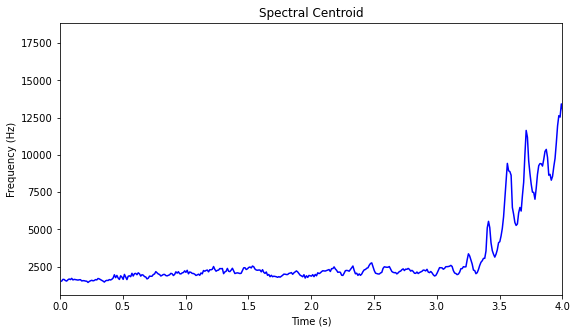

In [108]:
plt.figure(figsize=(9,5))
plt.plot(t, spectral_centroids[0], color='b');
plt.xlim([0, 4])
# plt.ylim([1500, 18000])
plt.xlabel('Time (s)')
plt.ylabel("Frequency (Hz)")
plt.title('Spectral Centroid');

### 2. Spectral rolloff

In [98]:
spectral_rolloff = librosa.feature.spectral_rolloff(x, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.85)

In [100]:
spectral_rolloff.shape

(1, 504)

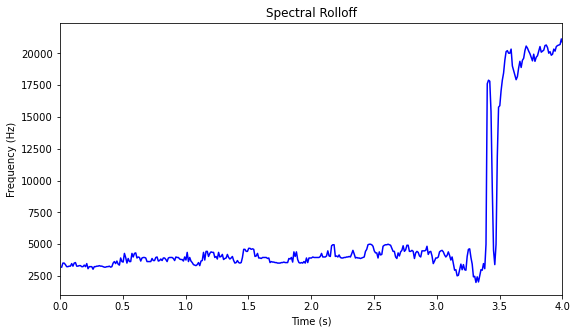

In [107]:
plt.figure(figsize=(9,5))
plt.plot(t, spectral_rolloff[0], color='b');
plt.xlim([0, 4])
# plt.ylim([1500, 18000])
plt.xlabel('Time (s)')
plt.ylabel("Frequency (Hz)")
plt.title('Spectral Rolloff');

### 3. Order-$p$ spectral bandwidth

In [102]:
spectral_bandwidth_2 = librosa.feature.spectral_bandwidth(x, sr=sr, 
                                                          n_fft=n_fft, hop_length=hop_length, 
                                                          p=2)[0]

In [104]:
spectral_bandwidth_2.shape

(504,)

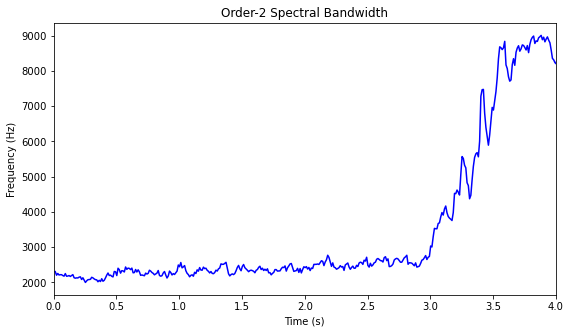

In [106]:
plt.figure(figsize=(9,5))
plt.plot(t, spectral_bandwidth_2, color='b');
plt.xlim([0, 4])
# plt.ylim([1500, 18000])
plt.xlabel('Time (s)')
plt.ylabel("Frequency (Hz)")
plt.title('Order-2 Spectral Bandwidth');

### 4. Zero-Crossing Rate (ZCR)

In [111]:
zcr = librosa.feature.zero_crossing_rate(x, frame_length=n_fft, hop_length=hop_length)

In [112]:
zcr.shape

(1, 504)

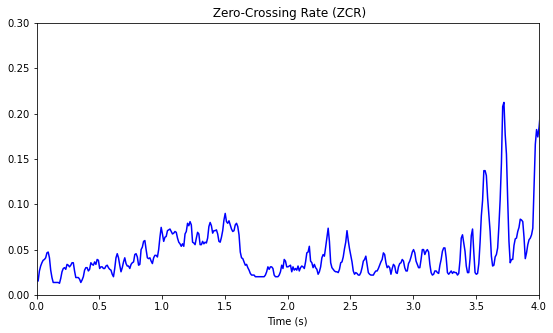

In [116]:
plt.figure(figsize=(9,5))
plt.plot(t, zcr[0], color='b');
plt.xlim([0, 4])
plt.ylim([0, 0.3])
plt.xlabel('Time (s)')
# plt.ylabel("Frequency (Hz)")
plt.title(' Zero-Crossing Rate (ZCR)');

### 5. Mel-Frequency Cepstral Coefficients(MFCCs)

In [117]:
mfcc = librosa.feature.mfcc(x, sr=sr, n_mfcc=20)

In [118]:
mfcc.shape

(20, 434)

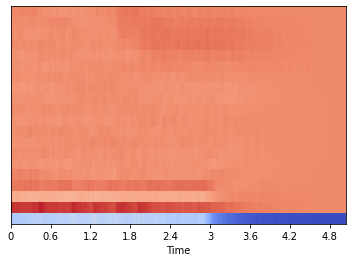

In [127]:
# plot MFCCs
# plt.figure(figsize=(15, 7))
librosa.display.specshow(mfcc, sr=sr, x_axis='time');

### 6. Chroma feature

In [141]:
chromagram = librosa.feature.chroma_stft(x, sr=sr, n_fft=n_fft, hop_length=hop_length)

In [144]:
chromagram.shape

(12, 504)

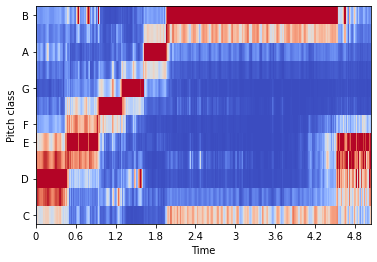

In [145]:
# plot chromagram
librosa.display.specshow(chromagram, sr=sr, x_axis='time', y_axis='chroma', 
                         hop_length=hop_length, cmap='coolwarm');